[1] 라이브러리 불러오기

In [ ]:
import cv2
import os
import math
from collections import deque
import numpy as np

[2] VehicleState 클래스 – 차량의 속도/방향 계산 및 저장

In [ ]:
class VehicleState:
    def __init__(self, vehicle_id):
        self.id = vehicle_id
        self.positions = deque(maxlen=10)  # 최근 위치 (frame_id, x, y)
        self.velocity = 0.0  # m/s
        self.direction = 0.0  # degrees

    def update(self, frame_id, x, y, pixel_to_meter, frame_rate=30):
        self.positions.append((frame_id, x, y))

        if len(self.positions) >= 2:
            (f1, x1, y1), (f2, x2, y2) = self.positions[-2], self.positions[-1]
            dt = (f2 - f1) / frame_rate
            if dt > 0:
                dx = (x2 - x1) * pixel_to_meter
                dy = (y2 - y1) * pixel_to_meter
                distance = math.hypot(dx, dy)
                self.velocity = distance / dt
                self.direction = math.degrees(math.atan2(dy, dx))

[3] 캘리브레이션 함수 – 픽셀 → 실제 거리 변환 비율 계산

In [ ]:
def estimate_pixel_to_meter(lane_pixel_gap=70, real_lane_gap_m=3.5):
    return real_lane_gap_m / lane_pixel_gap  # 예: 1 pixel ≈ 0.05m

[4] IoU 계산 함수

In [ ]:
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0.0

    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]
    return interArea / float(boxAArea + boxBArea - interArea)

[5] 차량 ID 매칭 함수 (IoU 기반)

In [ ]:
def match_vehicles(prev_boxes, curr_boxes, iou_threshold=0.3):
    matched = {}
    used = set()
    unmatched = set(curr_boxes.keys())

    for pid, pb in prev_boxes.items():
        best_iou = 0
        best_cid = None
        for cid, cb in curr_boxes.items():
            if cid in used:
                continue
            iou = compute_iou(pb, cb)
            if iou > best_iou:
                best_iou = iou
                best_cid = cid
        if best_iou >= iou_threshold:
            matched[pid] = best_cid
            used.add(best_cid)
            unmatched.discard(best_cid)

    return matched, unmatched

[6] TrackerManager 클래스 – 차량 전체 상태 관리

In [ ]:
class TrackerManager:
    def __init__(self, pixel_to_meter=0.05, frame_rate=30):
        self.states = {}  # {id: VehicleState}
        self.prev_detections = {}  # {id: (x, y, w, h)}
        self.pixel_to_meter = pixel_to_meter
        self.frame_rate = frame_rate
        self.next_id = 0

    def update(self, frame_id, curr_boxes):
        matched, unmatched = match_vehicles(self.prev_detections, curr_boxes)
        new_states = {}

        # 기존 ID 차량 갱신
        for pid, cid in matched.items():
            x, y, w, h = curr_boxes[cid]
            cx, cy = x + w // 2, y + h // 2
            self.states[pid].update(frame_id, cx, cy, self.pixel_to_meter, self.frame_rate)
            new_states[pid] = curr_boxes[cid]

        # 새로운 ID 차량 등록
        for cid in unmatched:
            x, y, w, h = curr_boxes[cid]
            cx, cy = x + w // 2, y + h // 2
            sid = self.next_id
            self.next_id += 1
            self.states[sid] = VehicleState(sid)
            self.states[sid].update(frame_id, cx, cy, self.pixel_to_meter, self.frame_rate)
            new_states[sid] = curr_boxes[cid]

        self.prev_detections = new_states

[7] 차량 검출 함수 – 밝기 기반 단순 검출

In [ ]:
def detect_vehicles(frame):
    detections = {}
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    idx = 0
    for cnt in contours:
        if cv2.contourArea(cnt) > 500:
            x, y, w, h = cv2.boundingRect(cnt)
            detections[idx] = (x, y, w, h)
            idx += 1
    return detections

[8] 시각화 함수 – 속도와 방향 표시

In [ ]:
def visualize(frame, tracker):
    for vid, state in tracker.states.items():
        if len(state.positions) == 0:
            continue
        x, y = state.positions[-1][1], state.positions[-1][2]
        speed = state.velocity
        angle = state.direction
        cv2.circle(frame, (int(x), int(y)), 5, (0, 255, 0), -1)
        label = f"ID:{vid} {speed:.1f} m/s {angle:.1f}°"
        cv2.putText(frame, label, (int(x)+10, int(y)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

[9] 실행 함수 – 이미지 폴더에 대해 트래킹 실행

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def cv2_imshow_safe(image, delay=1):
    import sys
    if 'google.colab' in sys.modules:
        from google.colab.patches import cv2_imshow
        cv2_imshow(image)
    else:
        cv2.imshow("Tracking", image)
        cv2.waitKey(delay)

In [ ]:
def run_tracking_on_images(image_folder, save_video=True, out_path="/content/tracking_result.mp4", fps=30):
    import os
    import cv2

    # 이미지 경로 수집
    image_paths = sorted([
        os.path.join(image_folder, f)
        for f in os.listdir(image_folder)
        if f.lower().endswith(('.jpg', '.png'))
    ])

    if len(image_paths) == 0:
        print("⚠️ 이미지가 없습니다. 경로를 확인하세요:", image_folder)
        return

    # 트래커 초기화
    tracker = TrackerManager(pixel_to_meter=estimate_pixel_to_meter())
    frames = []

    for frame_id, path in enumerate(image_paths):
        frame = cv2.imread(path)
        detections = detect_vehicles(frame)
        tracker.update(frame_id, detections)
        visualize(frame, tracker)
        frames.append(frame.copy())

        # Colab에서는 imshow 대신 안전 함수 사용
        if frame_id < 5:
            cv2_imshow_safe(frame)

    # 영상 저장
    if save_video and frames:
        height, width, _ = frames[0].shape
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        video = cv2.VideoWriter(out_path, fourcc, fps, (width, height))
        for f in frames:
            video.write(f)
        video.release()
        print("✅ 영상 저장 완료:", out_path)
    else:
        print("✅ 영상 저장 없이 시각화만 수행 완료.")

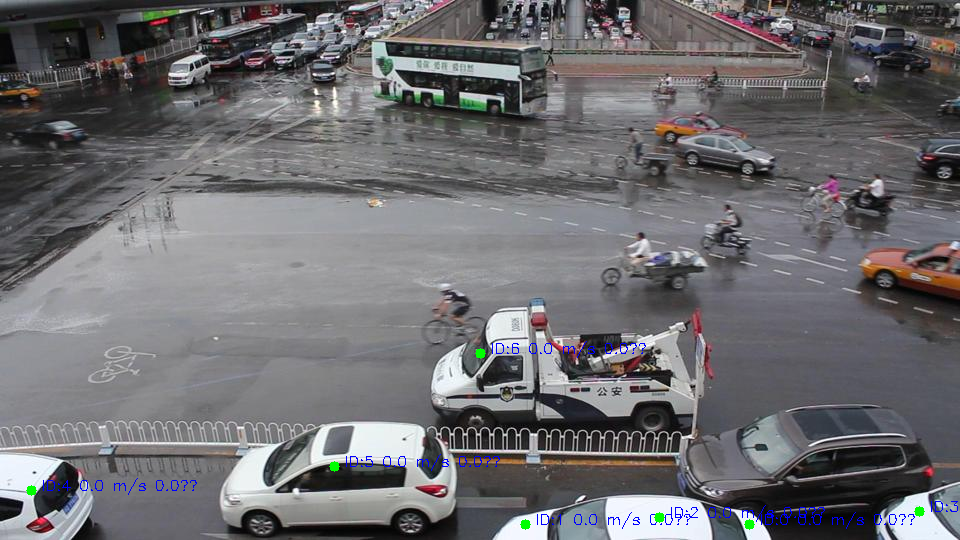

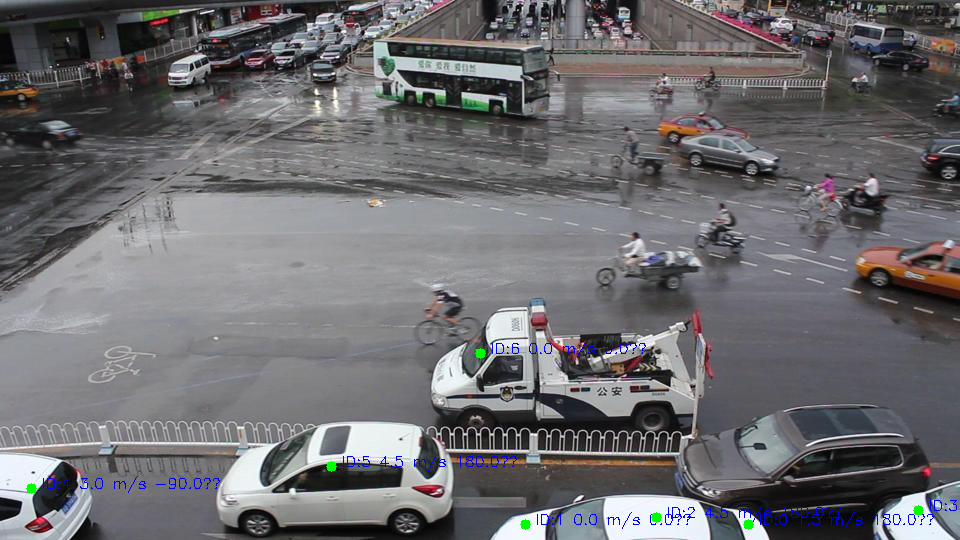

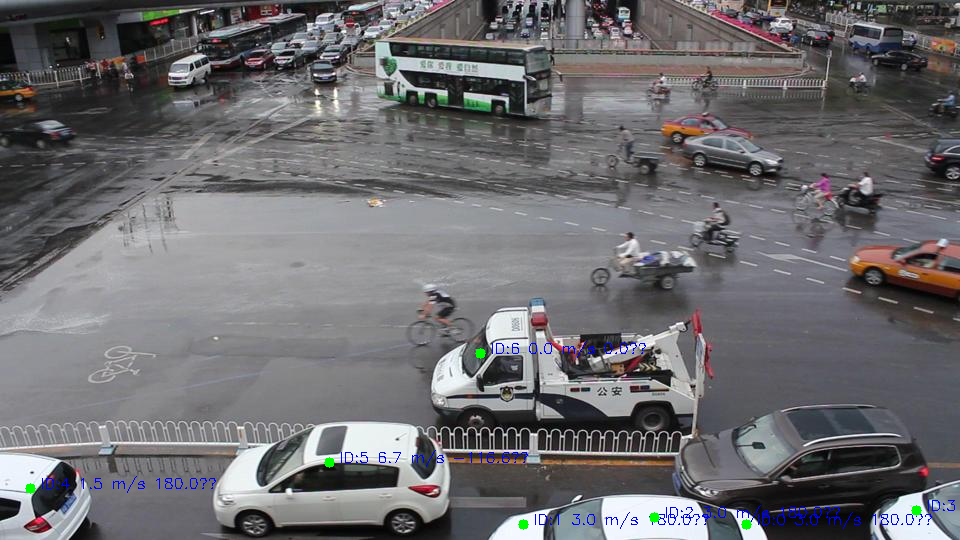

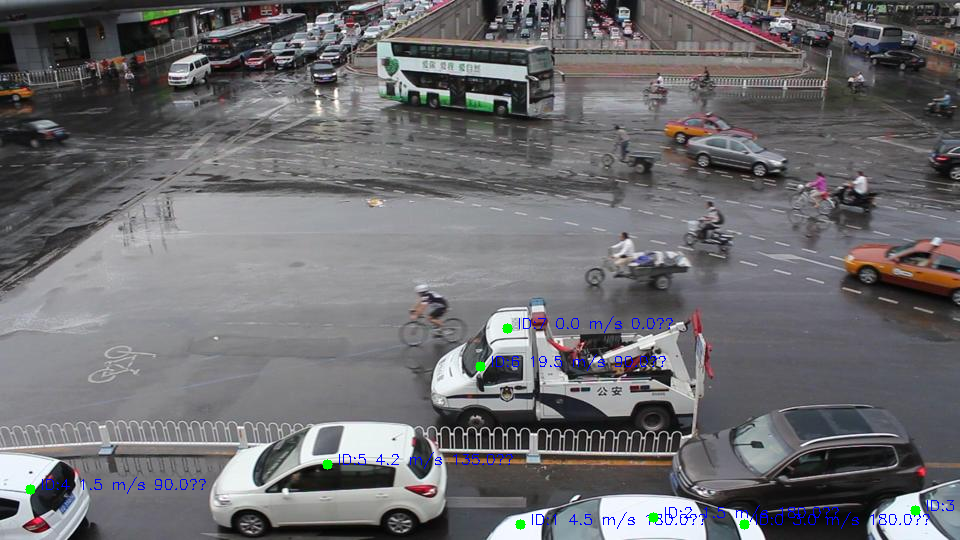

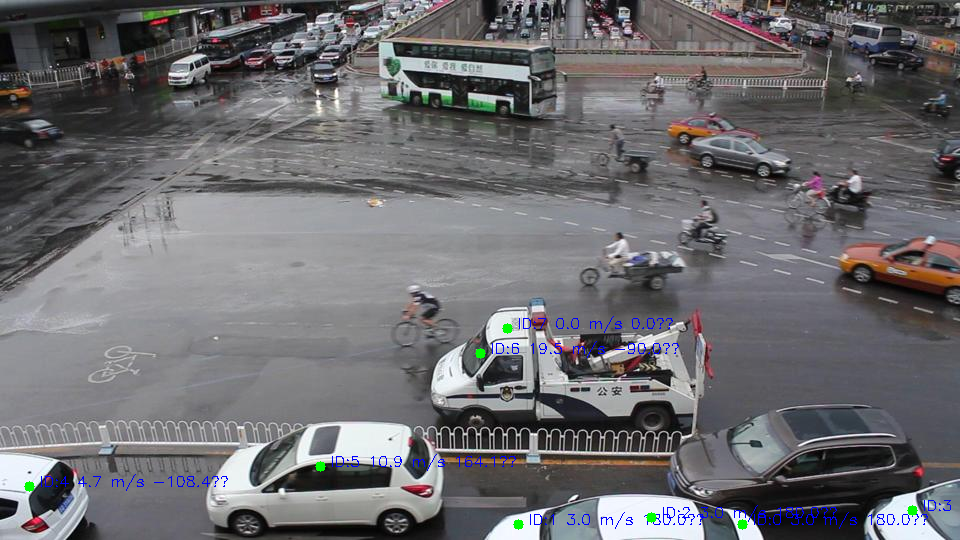

✅ 영상 저장 완료: /content/tracking_result.mp4


In [ ]:
run_tracking_on_images("/content/drive/MyDrive/tracking_image3")